In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scipy

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.utils import parse_dict
from src.verifier import make_compute_returns

## Helpers

In [3]:
class StepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: chex.PRNGKey
    observations: chex.Array
    actions: chex.Array
    answers: chex.Array
    pointer_correct: chex.Array
    is_prompt: chex.Array
    eos: chex.Array
    logits: chex.Array
    step_i: int = 0
    deterministic: int = 0
    """
    XXX: Set both to zero if we're using CoT tokens or predicting <EOS>

    XXX: Assume that all possible responses contain tokens with ID up to max_token_id_to_shift
         - You will have to include max_token_id_to_shift + 1 CoT tokens to get the code to run
    """
    correct_aware_shift: int = 0
    max_token_id_to_shift: int = 0


def predict_step(
    step_state: StepState,
):
    step_i = step_state.step_i
    rng, rng_step = jax.random.split(step_state.rng, 2)

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.rest, step_state.cache)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)
    logits = module({"sequence": step_state.observations[:, [step_i]],},)
    cache = nnx.state(module, nnx.Cache)

    logits = logits[:, 0]

    # Actual action taken, but output_tokens can be different
    action = jax.lax.cond(
        step_state.deterministic,
        lambda rng_step, logits: jnp.argmax(logits, axis=-1),
        jax.random.categorical,
        rng_step,
        logits,
    )

    is_prompt = step_state.is_prompt[:, step_i]
    pointer_correct = step_state.pointer_correct

    # Shift token by some amount if we know the steps are wrong
    curr_answers = step_state.answers[
        jnp.arange(len(pointer_correct)), pointer_correct
    ]

    pointer_correct = jnp.where(
        jnp.logical_and(
            jnp.logical_not(is_prompt),
            curr_answers == action,
        ),
        pointer_correct + 1,
        jnp.where(
            jnp.logical_and(
                step_state.answers[:, 0] != action,
                jnp.logical_not(is_prompt),
            ),
            0,
            1,
        )
    )

    output_tokens = jnp.where(
        jnp.logical_and(
            curr_answers != action,
            action <= step_state.max_token_id_to_shift,
        ),
        action + step_state.correct_aware_shift,
        action,
    )

    # jax.debug.print(
    #     "step {w} is_prompt {v}: pointer {x} answer {y} pred {u} transition {z}",
    #     w=step_i,
    #     v=is_prompt,
    #     x=pointer_correct,
    #     y=curr_answers,
    #     u=action,
    #     z=output_tokens,
    # )

    # Check for prompt boundary
    output_tokens = jnp.where(
        is_prompt,
        step_state.observations[:, step_i + 1],
        output_tokens,
    )

    # Check if the first EOS has been generated
    eos = jnp.logical_or(
        output_tokens == step_state.eos_token,
        step_state.eos[:, step_i],
    )

    # Update the entries on the i'th step
    observations = step_state.observations.at[:, step_i + 1].set(output_tokens)
    actions = step_state.actions.at[:, step_i + 1].set(action)
    eos = step_state.eos.at[:, step_i + 1].set(eos)
    all_logits = step_state.logits.at[:, step_i + 1].set(logits)

    step_state = StepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        observations=observations,
        actions=actions,
        answers=step_state.answers,
        pointer_correct=pointer_correct,
        is_prompt=step_state.is_prompt,
        eos=eos,
        step_i=step_i + 1,
        deterministic=step_state.deterministic,
        correct_aware_shift=step_state.correct_aware_shift,
        max_token_id_to_shift=step_state.max_token_id_to_shift,
        logits=all_logits,
    )

    return step_state


@nnx.jit(static_argnames=["out_dim"])
def rollout(
    graphdef: Any,
    cache: Any,
    rest: Any,
    rng: chex.PRNGKey,
    batch: Any,
    out_dim: int,
    eos_token: int,
    deterministic: int = 0,
    correct_aware_shift: int = 0,
    max_token_id_to_shift: int = 0,
):
    questions = batch["sequence"]
    answers = batch["target"]
    mask = batch["mask"]
    num_questions, max_step = questions.shape

    step_state = StepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        eos_token=eos_token,
        rng=rng,
        observations=questions,
        actions=jnp.zeros_like(questions, dtype=int),
        answers=answers,
        pointer_correct=jnp.ones((num_questions,), dtype=int),
        is_prompt=1 - mask,
        eos=jnp.zeros((num_questions, max_step)),
        deterministic=deterministic,
        correct_aware_shift=correct_aware_shift,
        max_token_id_to_shift=max_token_id_to_shift,
        logits=jnp.zeros((num_questions, max_step, out_dim)),
    )

    step_state = jax.lax.while_loop(
        lambda state: state.step_i < max_step - 1,
        predict_step,
        step_state,
    )

    return {
        "observations": step_state.observations,
        "actions": step_state.actions,
        "eos": step_state.eos,
        "is_prompt": step_state.is_prompt,
        "logits": step_state.logits,
    }


In [4]:
Dtype = Any
Shape = tuple[int, ...]
EOS_TOKEN = 6

@runtime_checkable
class HasCache(Protocol):
    def init_cache(self, input_shape: Shape, dtype: Dtype = jnp.float32): ...

def evaluate(
    learner_path,
    batch,
    out_dim,
    batch_size,
    eval_seed,
    num_evals,
    max_decode_len,
    dtype,
    checkpoint_i=-1,
    stochastic=False,
    correct_aware_shift: int = 0,
    max_token_id_to_shift: int = 0,
):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

    # Load model
    last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
    train_state = dill.load(
        open(os.path.join(learner_path, "models", last_step), "rb")
    )

    # print(train_state.params)
    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    rng = jax.random.PRNGKey(eval_seed)
    rng, rollout_rng = jax.random.split(rng)

    # Sample next batch and evaluate
    _, init_cache = make_autoregressive(
        model,
        max_decode_len=max_decode_len,
        batch_size=batch_size * num_evals,
        embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

    rollout_res = rollout(
        graphdef,
        cache,
        rest,
        rollout_rng,
        batch,
        out_dim=out_dim,
        eos_token=EOS_TOKEN,
        deterministic=1 - int(stochastic),
        correct_aware_shift=correct_aware_shift,
        max_token_id_to_shift=max_token_id_to_shift,
    )

    return rollout_res

## Evaluate

In [5]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

algo_name = "addition-max_int_64-no_eos"
run_name = "ppo-scratch-1x64-stop_on_empty-max_int_8-10-07-25_03_49_44-81ad5db5-0847-4b43-a42d-ad6cd7e24cd7"
run_name = "ppo-scratch-8x8-2_cot_tokens-stop_on_empty-max_int_8-10-07-25_04_35_16-1fc5c97e-b2ef-47ca-b87f-2a0a41f65b27"
run_name = "ppo-scratch-8x8-2_cot_tokens-stop_on_empty-max_int_64-curriculum-10-08-25_05_34_47-78034737-f93e-4a5a-9aa6-fa1e1ee68fe0"
run_name = "supervised-nope-scratch-32-noop_p0.1_m5-stop_on_empty-10-13-25_03_46_02-7da06c7f-2f4a-4bda-a16c-834072183754"
run_name = "supervised-nope-scratch-32-noop_p0.1_m5_pad-stop_on_empty-10-13-25_07_16_31-afb1ab65-6a45-4a40-a393-6bac0a798aed"
run_name = "ppo-scratch_1M-correctness_aware-8x8-stop_on_empty-10-15-25_04_45_42-77e868f9-e372-48bc-9f43-cac02a68c54d"

learner_path = os.path.join(base_path, algo_name, run_name)

In [6]:
save_filename = f"res-{run_name}.dill"

eval_seed = 42
num_evals = 5
max_batch_size = 200
max_decode_len = 200

config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
train_max_int = config_dict["dataset_kwargs"]["max_int"]
config_dict["dataset_kwargs"]["max_int"] = 4096
config_dict["gamma"] = 0.99
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs

num_checkpoints = len(os.listdir(os.path.join(learner_path, "models")))
if os.path.isfile(save_filename):
    print("Loaded from storage")
    all_res = dill.load(open(save_filename, "rb"))
else:
    all_res = dict(
        results=dict(),
        metrics=dict(),
    )

    print(f"Max decode len: {max_decode_len}")

    if config.dataset_name == "curriculum":
        max_num_bits = int(np.ceil(np.log2(dataset_kwargs.datasets[-1]["dataset_kwargs"]["max_int"])))
        train_val_ratio = dataset_kwargs.datasets[-1]["dataset_kwargs"]["train_val_ratio"]
        predict_eos = dataset_kwargs.datasets[-1]["dataset_kwargs"]["predict_eos"]
        num_cot_tokens = dataset_kwargs.datasets[-1]["dataset_kwargs"]["num_cot_tokens"]
        right_to_left = dataset_kwargs.datasets[-1]["dataset_kwargs"]["right_to_left"]
    else:
        max_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
        train_val_ratio = dataset_kwargs.train_val_ratio
        predict_eos = dataset_kwargs.predict_eos
        num_cot_tokens = dataset_kwargs.num_cot_tokens
        right_to_left = dataset_kwargs.right_to_left

    for num_bits in range(1, max_num_bits + 1):
        curr_int = 2 ** num_bits
        num_pairs = curr_int * curr_int
        num_val = num_pairs - int(np.floor(num_pairs * train_val_ratio))
        batch_size = min(num_val, max_batch_size)
        dataset = Addition(
            context_len=max_decode_len,
            max_int=curr_int,
            train=False,
            seed=eval_seed,
            sequence_type="question_only",
            train_val_ratio=train_val_ratio,
            right_to_left=right_to_left,
            num_repeats=None,
            shuffle=False,
            exact=True,
            predict_eos=predict_eos,
            num_cot_tokens=num_cot_tokens,
            p_curriculum=0.0,
            p_inject_noop=0.0,
            max_noops=0,
            noop_as_pad=False,
        )

        compute_returns = make_compute_returns(config, EOS_TOKEN)

        print(f"Max int: {curr_int}, batch size: {batch_size}")

        out_dim = int(dataset.output_space.n)
        data_loader = DataLoader(
            dataset,
            batch_size=batch_size,
            num_workers=0,
        )
        data_iter = get_iter(data_loader, None, dtype)
        batch = next(data_iter)
        batch = {
            "sequence": np.repeat(batch["sequence"], num_evals, axis=0),
            "mask": np.repeat(batch["mask"], num_evals, axis=0),
            "target": np.repeat(batch["target"], num_evals, axis=0),
        }

        for checkpoint_i in range(num_checkpoints):
            all_res["results"].setdefault(checkpoint_i, dict())
            all_res["metrics"].setdefault(checkpoint_i, dict())

            all_res["results"][checkpoint_i][num_bits] = evaluate(
                learner_path=learner_path,
                batch=batch,
                out_dim=out_dim,
                batch_size=batch_size,
                eval_seed=eval_seed,
                num_evals=num_evals,
                max_decode_len=max_decode_len,
                dtype=dtype,
                checkpoint_i=checkpoint_i,
                stochastic=True,
                correct_aware_shift=getattr(config, "correctness_aware_tokens_offset", 0),
                max_token_id_to_shift=getattr(config, "max_token_id_to_shift", 0),
            )

            returns, successes, response_lengths = compute_returns(
                {
                    "sequence": batch["sequence"],
                    "target": batch["target"],
                    "observations": all_res["results"][checkpoint_i][num_bits]["observations"],
                    "actions": all_res["results"][checkpoint_i][num_bits]["actions"],
                },
                all_res["results"][checkpoint_i][num_bits]["eos"],
                all_res["results"][checkpoint_i][num_bits]["is_prompt"],
                is_eval=False,
            )

            all_res["metrics"][checkpoint_i][num_bits] = {
                "successes": successes.reshape((batch_size, num_evals)),
                "response_lengths": response_lengths.reshape((batch_size, num_evals)),
            }
    dill.dump(all_res, open(save_filename, "wb"))

Loaded from storage


## Response Length and Success Rates

In [7]:
skip_step = 10
checkpoints = None

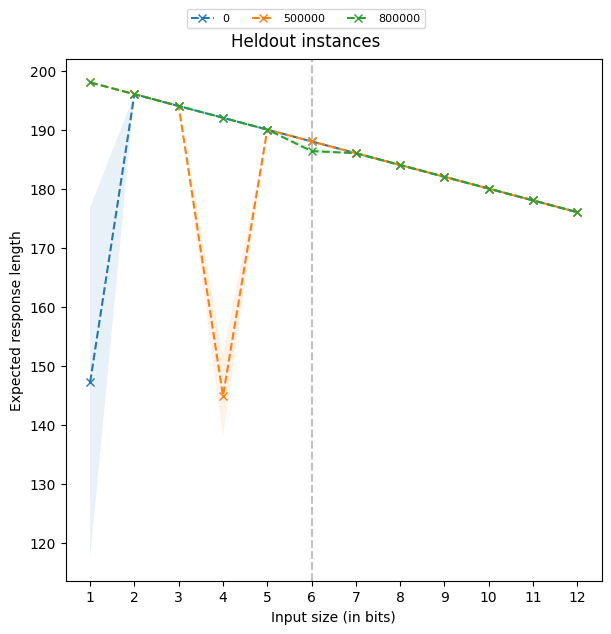

In [8]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    input_length_range = sorted(curr_metric.keys())
    expected_response_lengths = []
    for num_bits in input_length_range:
        expected_response_lengths.append((
            np.mean(curr_metric[num_bits]["response_lengths"]),
            np.std(curr_metric[num_bits]["response_lengths"]) / np.sqrt(
                curr_metric[num_bits]["response_lengths"].shape[0]
                * curr_metric[num_bits]["response_lengths"].shape[1]
            ),
        ))

    expected_response_lengths = np.array(expected_response_lengths)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
    ax.plot(
        input_length_range,
        expected_response_lengths[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_response_lengths[:, 0] + expected_response_lengths[:, 1],
        expected_response_lengths[:, 0] - expected_response_lengths[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Expected response length")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

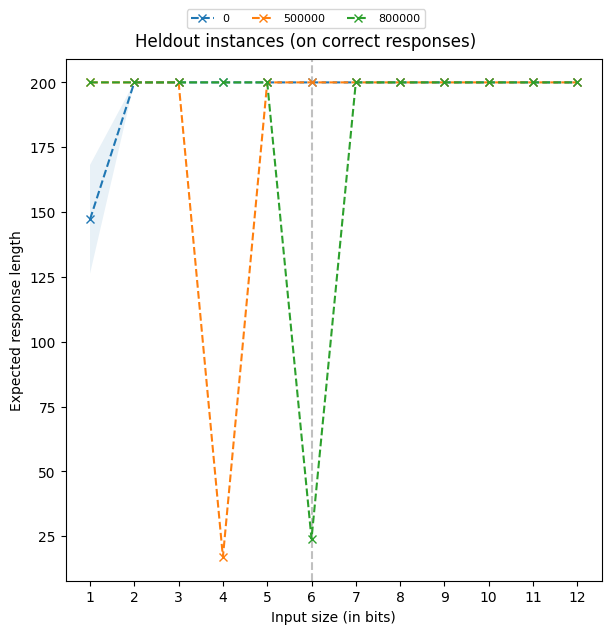

In [9]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    input_length_range = sorted(curr_metric.keys())
    expected_response_lengths = []
    for num_bits in input_length_range:
        success_runs = np.where(curr_metric[num_bits]["successes"])[0]
        if len(success_runs) == 0:
            expected_response_lengths.append((max_decode_len, 0.0))
        else:    
            expected_response_lengths.append((
                np.mean(curr_metric[num_bits]["response_lengths"][success_runs]),
                np.std(curr_metric[num_bits]["response_lengths"][success_runs]) / np.sqrt(
                    curr_metric[num_bits]["response_lengths"][success_runs].shape[0]
                    * curr_metric[num_bits]["response_lengths"][success_runs].shape[1]
                ),
            ))

    expected_response_lengths = np.array(expected_response_lengths)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
    ax.plot(
        input_length_range,
        expected_response_lengths[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_response_lengths[:, 0] + expected_response_lengths[:, 1],
        expected_response_lengths[:, 0] - expected_response_lengths[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Expected response length")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances (on correct responses)")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

[0.4 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
[0.         0.         0.         0.26923077 0.         0.
 0.         0.         0.         0.         0.         0.        ]
[0.   0.   0.   0.   0.   0.01 0.   0.   0.   0.   0.   0.  ]


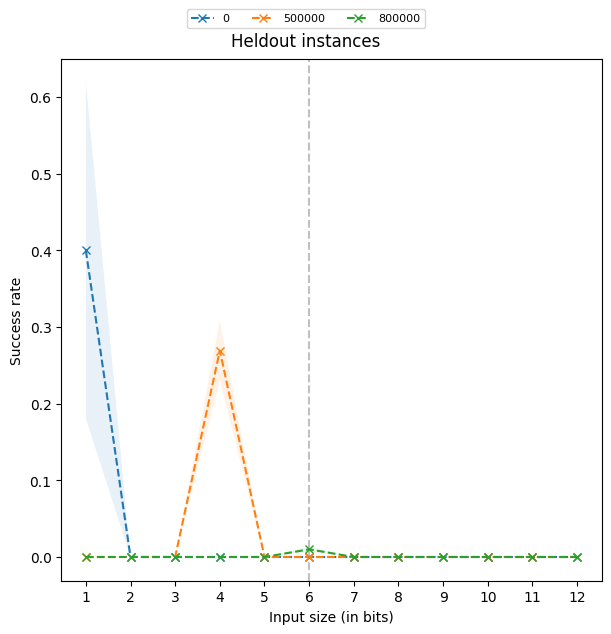

In [10]:
fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))
for checkpoint_i, curr_metric in all_res["metrics"].items():
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    input_length_range = sorted(curr_metric.keys())
    expected_successes = []
    for num_bits in input_length_range:
        expected_successes.append((
            np.mean(curr_metric[num_bits]["successes"]),
            np.std(curr_metric[num_bits]["successes"]) / np.sqrt(
                curr_metric[num_bits]["successes"].shape[0]
                * curr_metric[num_bits]["successes"].shape[1]
            ),
        ))

    expected_successes = np.array(expected_successes)

    ax.axvline(np.ceil(np.log2(train_max_int)), linestyle="--", c="gray", alpha=0.2)
    print(expected_successes[:, 0])
    ax.plot(
        input_length_range,
        expected_successes[:, 0],
        marker="x",
        linestyle="--",
        label=f"{checkpoint_i * checkpoint_interval}",
    )
    ax.fill_between(
        input_length_range,
        expected_successes[:, 0] + expected_successes[:, 1],
        expected_successes[:, 0] - expected_successes[:, 1],
        alpha=0.1,
    )
    ax.set_xticks(input_length_range)
    ax.set_ylabel("Success rate")
    ax.set_xlabel("Input size (in bits)")

fig.suptitle("Heldout instances")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

## Entropy

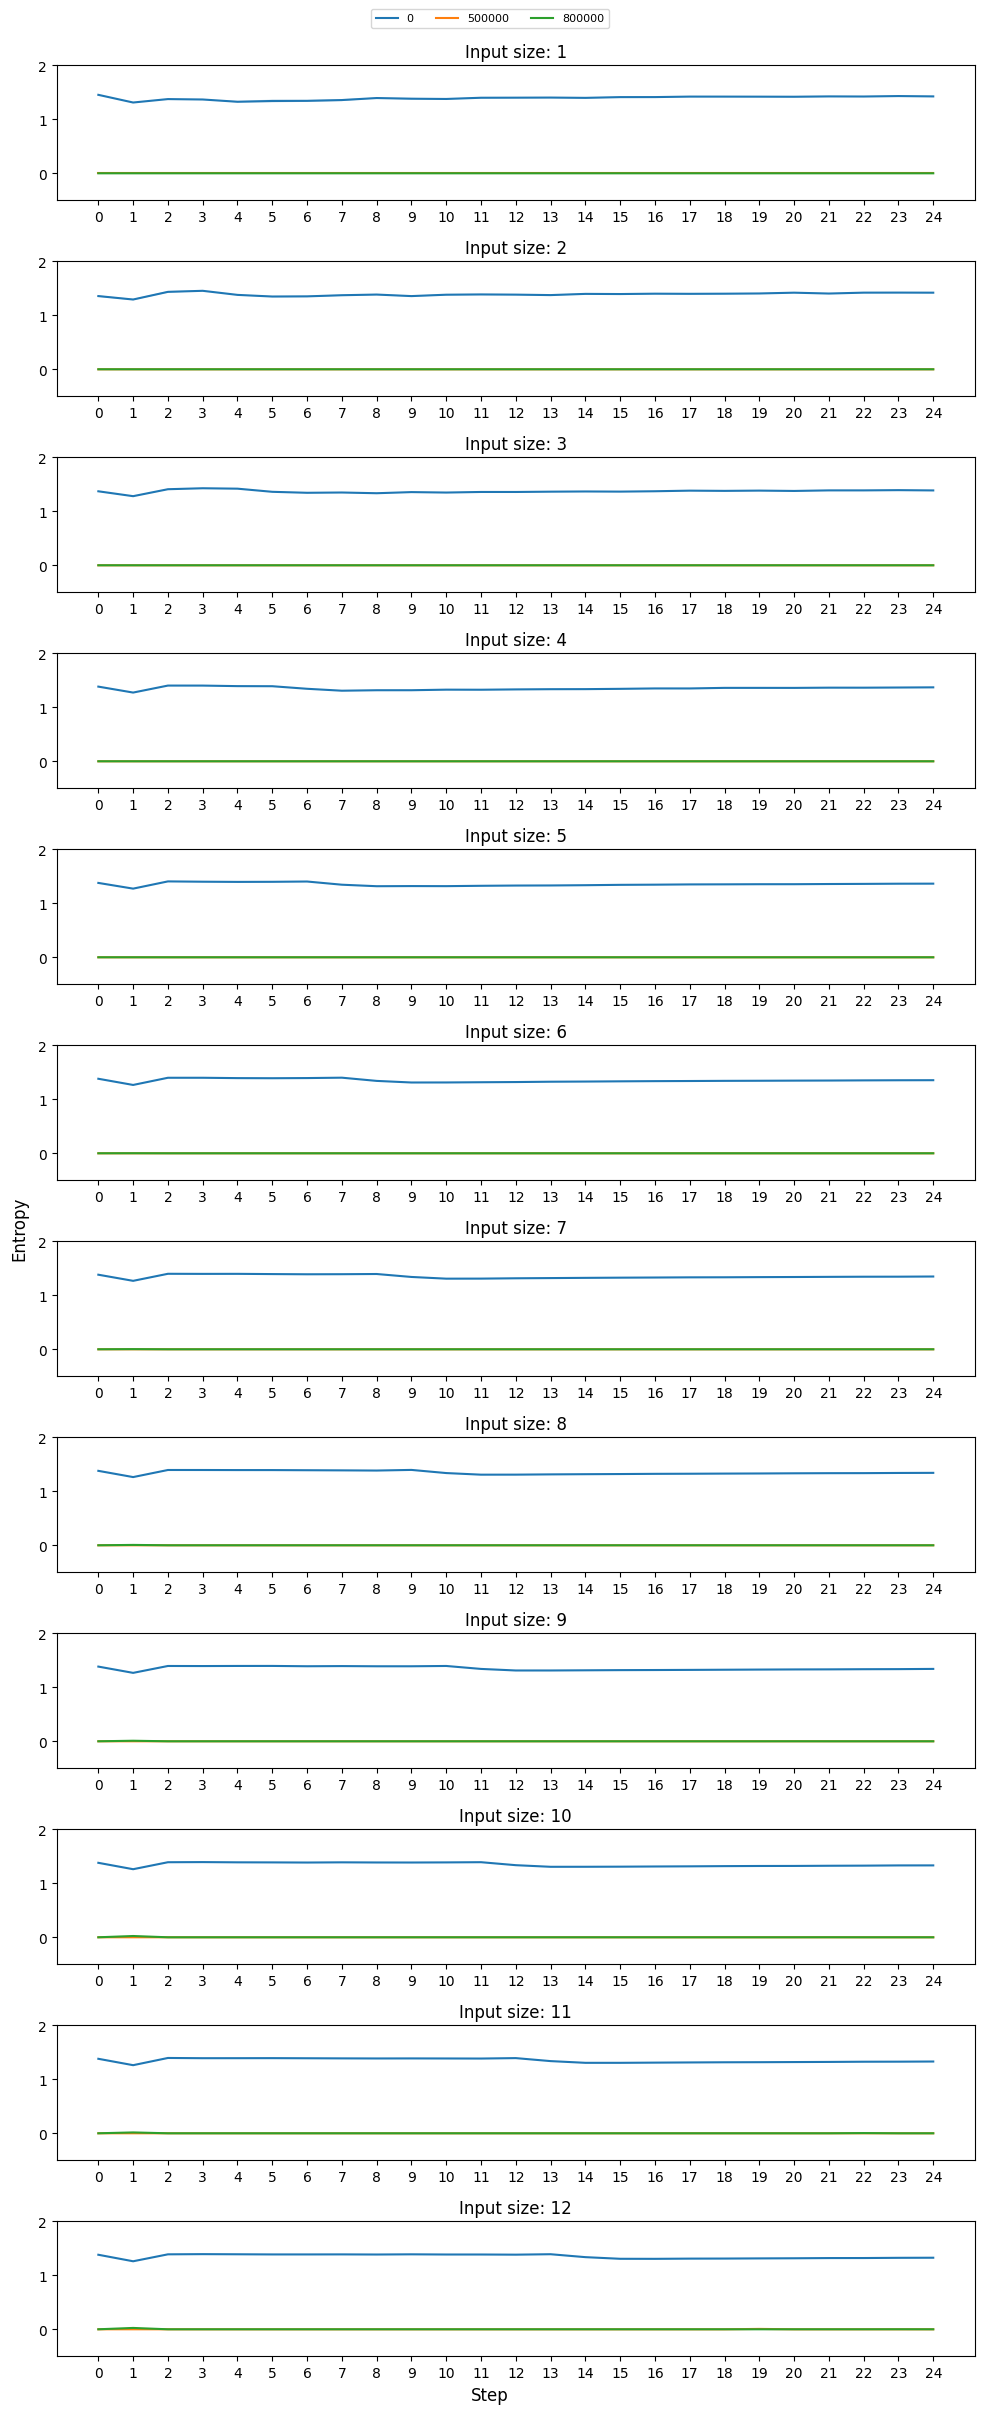

In [11]:
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(all_res["metrics"].keys()))

fig, axs = plt.subplots(
    len(all_res["results"][0]),
    1,
    figsize=(
        10,
        2 * len(all_res["results"][0])
    ),
)
for checkpoint_i in all_res["results"]:
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    for plot_i, (input_size, curr_res) in enumerate(all_res["results"][checkpoint_i].items()):
        logits = curr_res["logits"][..., input_size:, :]
        logits = logits.reshape((-1, *logits.shape[1:]))
        entropies = optax.softmax_cross_entropy(logits, jax.nn.softmax(logits, axis=-1))
        mean_entropy = jnp.mean(entropies, axis=0)[:max_x]
        std_entropy = (jnp.std(entropies, axis=0) / np.sqrt(len(entropies)))[:max_x]

        x_range = np.arange(len(mean_entropy))
        axs[plot_i].plot(
            x_range,
            mean_entropy,
            label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 0 else "",
        )
        axs[plot_i].fill_between(
            x_range,
            mean_entropy - std_entropy,
            mean_entropy + std_entropy,
            alpha=0.2,
        )

        axs[plot_i].set_title(f"Input size: {input_size}")
        axs[plot_i].set_xticks(x_range)
        axs[plot_i].set_ylim(-0.5, 2.0)

fig.supylabel('Entropy')
fig.supxlabel('Step')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()

## Check greedy actions

In [12]:
save_filename_match_results = f"res-{run_name}-match_results.dill"

if os.path.isfile(save_filename_match_results):
    print("Loaded from storage")
    match_results = dill.load(open(save_filename_match_results, "rb"))
else:
    match_results = dict()
    for checkpoint_i in all_res["results"].keys():
        match_results[checkpoint_i] = dict()
        for num_bits in range(1, max_num_bits + 1):
            match_results[checkpoint_i][num_bits] = dict()
            for bit_match_idx in range(max_num_bits):
                if bit_match_idx >= num_bits:
                    continue

                match_results[checkpoint_i][num_bits][bit_match_idx] = dict()
                curr_int = 2 ** num_bits
                num_pairs = curr_int * curr_int
                num_val = num_pairs - int(np.floor(num_pairs * train_val_ratio))
                batch_size = min(num_val, max_batch_size)

                dataset = Addition(
                    context_len=max_decode_len,
                    max_int=curr_int,
                    train=False,
                    seed=eval_seed,
                    sequence_type="question_only",
                    train_val_ratio=train_val_ratio,
                    right_to_left=right_to_left,
                    num_repeats=None,
                    shuffle=False,
                    exact=True,
                    predict_eos=predict_eos,
                    num_cot_tokens=num_cot_tokens,
                    p_curriculum=0.0,
                    p_inject_noop=0.0,
                    max_noops=0,
                    noop_as_pad=False,
                )
                data_loader = DataLoader(
                    dataset,
                    batch_size=batch_size,
                    num_workers=0,
                )
                data_iter = get_iter(data_loader, None, dtype)
                batch = next(data_iter)

                logits = all_res["results"][checkpoint_i][num_bits]["logits"]
                first_bit_match = (
                    batch["target"][:, 1 + bit_match_idx]
                    == np.argmax(logits[::5, num_bits * 2 + 2 + bit_match_idx], axis=-1)
                )

                # print("==" * 50)
                # print("Num bits: {}, bit {} match: {}% ({}/{})".format(
                #     num_bits,
                #     bit_match_idx + 1,
                #     np.mean(first_bit_match),
                #     np.sum(first_bit_match),
                #     first_bit_match.size,
                # ))

                match_results[checkpoint_i][num_bits][bit_match_idx]["bit_match"] = first_bit_match
                match_results[checkpoint_i][num_bits][bit_match_idx]["entropies"] = None

                not_matched_logits = logits[::5, num_bits * 2 + 2 + bit_match_idx][np.logical_not(first_bit_match)]
                if not_matched_logits.size > 0:
                    not_matched_logits = not_matched_logits.reshape(
                        (-1, *not_matched_logits.shape[1:])
                    )
                    unique_ints, counts = np.unique(
                        np.argmax(not_matched_logits, axis=-1),
                        return_counts=True,
                    )
                    entropies = optax.softmax_cross_entropy(
                        not_matched_logits,
                        jax.nn.softmax(not_matched_logits, axis=-1),
                    )
                    # print(
                    #     unique_ints, counts
                    # )
                    # print("Entropies for not matched: (med {:.5f}) (max {:.5f}) (min {:.5f})".format(
                    #     np.median(entropies),
                    #     np.max(entropies),
                    #     np.min(entropies),
                    # ))
                    match_results[checkpoint_i][num_bits][bit_match_idx]["entropies"] = entropies
    dill.dump(match_results, open(save_filename_match_results, "wb"))

NameError: name 'max_num_bits' is not defined

## Bit Match %

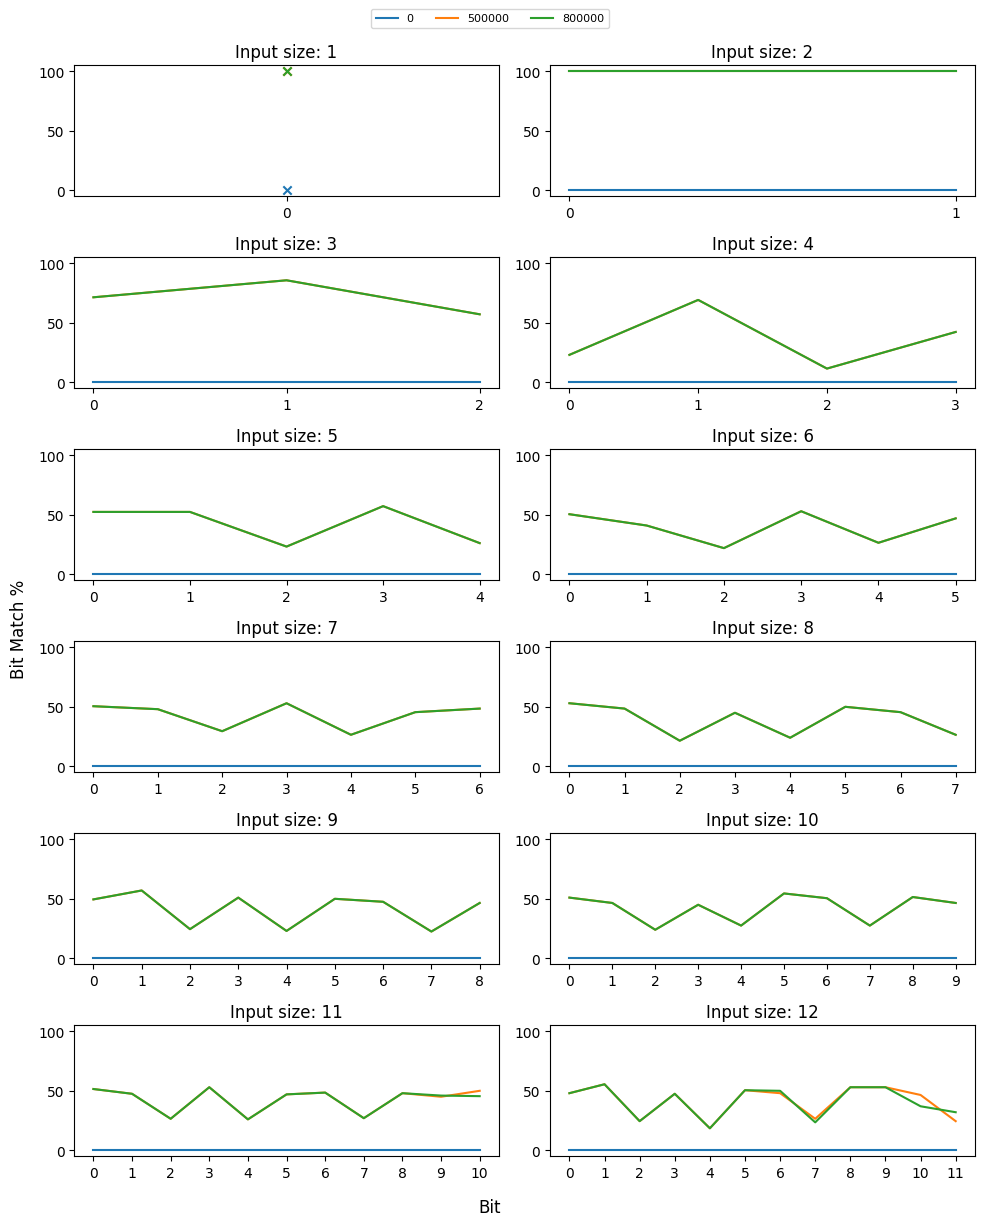

In [ ]:
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(match_results.keys()))

fig, axs = plt.subplots(
    int(np.ceil(len(match_results[0]) / 2)),
    2,
    figsize=(
        10,
        len(match_results[0])
    ),
)
axs = axs.flatten()
for checkpoint_i in match_results:
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    for plot_i, (input_size, curr_res) in enumerate(match_results[checkpoint_i].items()):
        x_range = sorted(list(curr_res.keys()))
        num_matches = [np.mean(curr_res[bit_match_idx]["bit_match"]) * 100 for bit_match_idx in x_range]
        
        if len(x_range) == 1:
            axs[plot_i].scatter(
                x_range,
                num_matches,
                marker="x"
            )
        else:
            axs[plot_i].plot(
                x_range,
                num_matches,
                label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 1 else "",
            )

        if checkpoint_i == 0:
            axs[plot_i].set_title(f"Input size: {input_size}")
            axs[plot_i].set_xticks(x_range)
            axs[plot_i].set_ylim(-5, 105)

fig.supylabel('Bit Match %')
fig.supxlabel('Bit')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()

## Entropy on incorrect instances

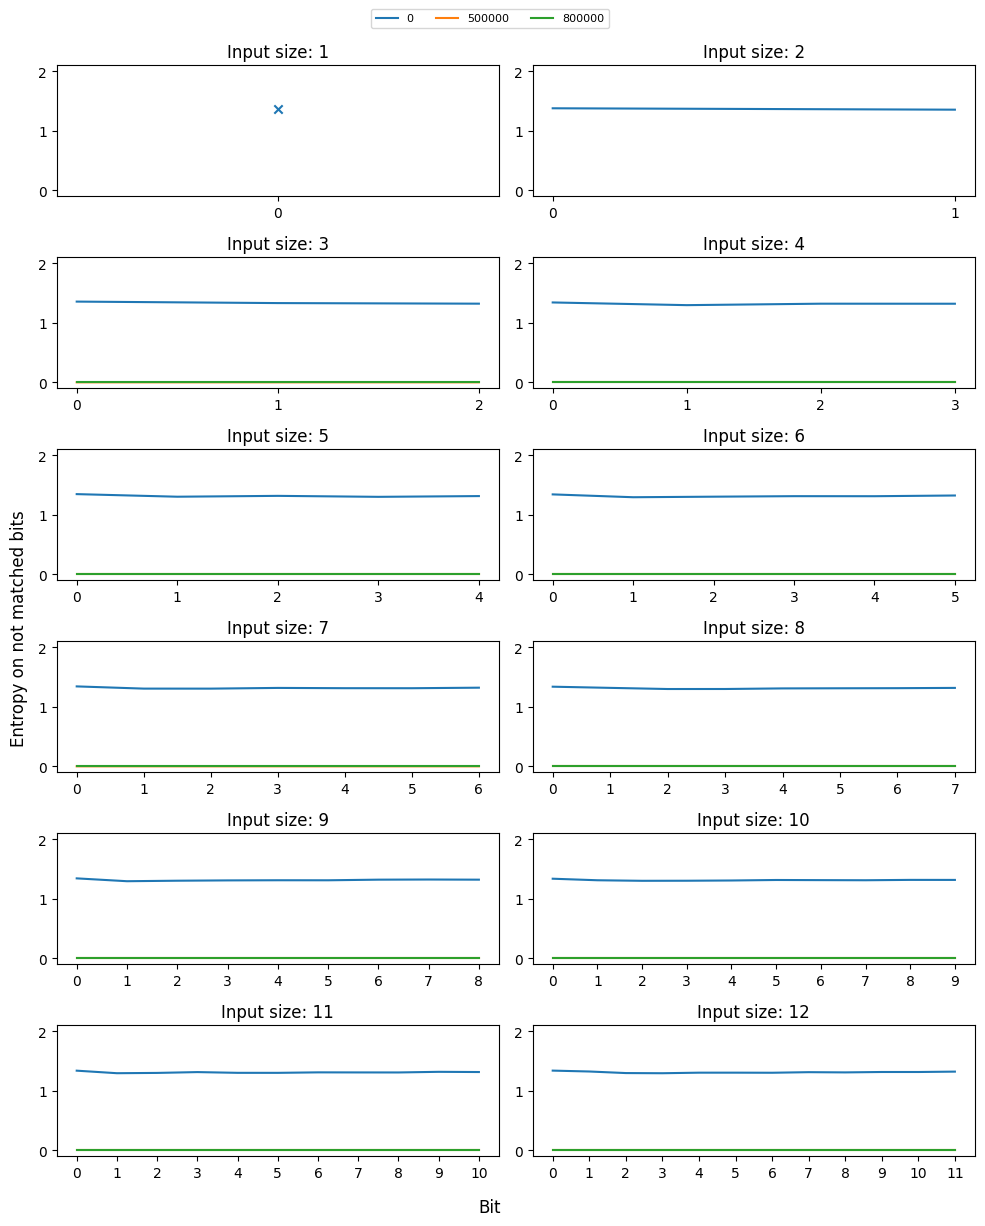

In [ ]:
max_x = min(max_decode_len, 25)
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(match_results.keys()))

fig, axs = plt.subplots(
    int(np.ceil(len(match_results[0]) / 2)),
    2,
    figsize=(
        10,
        len(match_results[0])
    ),
)
axs = axs.flatten()
for checkpoint_i in match_results:
    if checkpoints:
        if checkpoint_i not in checkpoints:
            continue
    else:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % skip_step != 0
        ):
            continue

    for plot_i, (input_size, curr_res) in enumerate(match_results[checkpoint_i].items()):
        x_range = list(filter(
            lambda bit_match_idx: curr_res[bit_match_idx]["entropies"] is not None,
            sorted(list(curr_res.keys())),
        ))
        entropies = [
            np.nanmedian(curr_res[bit_match_idx]["entropies"])
            for bit_match_idx in x_range
        ]
        
        if len(x_range) == 1:
            axs[plot_i].scatter(
                x_range,
                entropies,
                marker="x"
            )
        else:
            axs[plot_i].plot(
                x_range,
                entropies,
                label=f"{checkpoint_i * checkpoint_interval}" if plot_i == 1 else "",
            )

        if checkpoint_i == 0:
            axs[plot_i].set_title(f"Input size: {input_size}")
            axs[plot_i].set_xticks(x_range)
            axs[plot_i].set_ylim(-0.1, 2.1)

fig.supylabel('Entropy on not matched bits')
fig.supxlabel('Bit')
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)
plt.tight_layout()

### Note
`supervised-nope-scratch-32-noop_p0.1_m5-stop_on_empty-10-13-25_03_46_02-7da06c7f-2f4a-4bda-a16c-834072183754`
- Heldout instances of in-distribution length has 100% success rate, when supervised trained with CoT
- When trained with 1M steps, the first bit matches on all compared out-of-distribution length instances (200 instances)
    - Error starts compounding after that
    - Earlier model fails on shorter length instances

## Entropy in sampled trajectories

In [ ]:
curr_actions = all_res["results"][16][6]["actions"]
curr_actions = curr_actions.reshape((-1, 5, curr_actions.shape[-1]))

In [ ]:
curr_obss = all_res["results"][16][6]["observations"]
curr_obss = curr_obss.reshape((-1, num_evals, curr_obss.shape[-1]))

In [ ]:
all_matches = True
question_end_idx = np.where(curr_obss[0][0] == 3)[0][0]
for eval_i in range(num_evals):
    all_matches = all_matches and np.all(curr_obss[0][0, :question_end_idx] == curr_obss[0][eval_i, :question_end_idx])
    if not all_matches:
        break

print(all_matches)

True


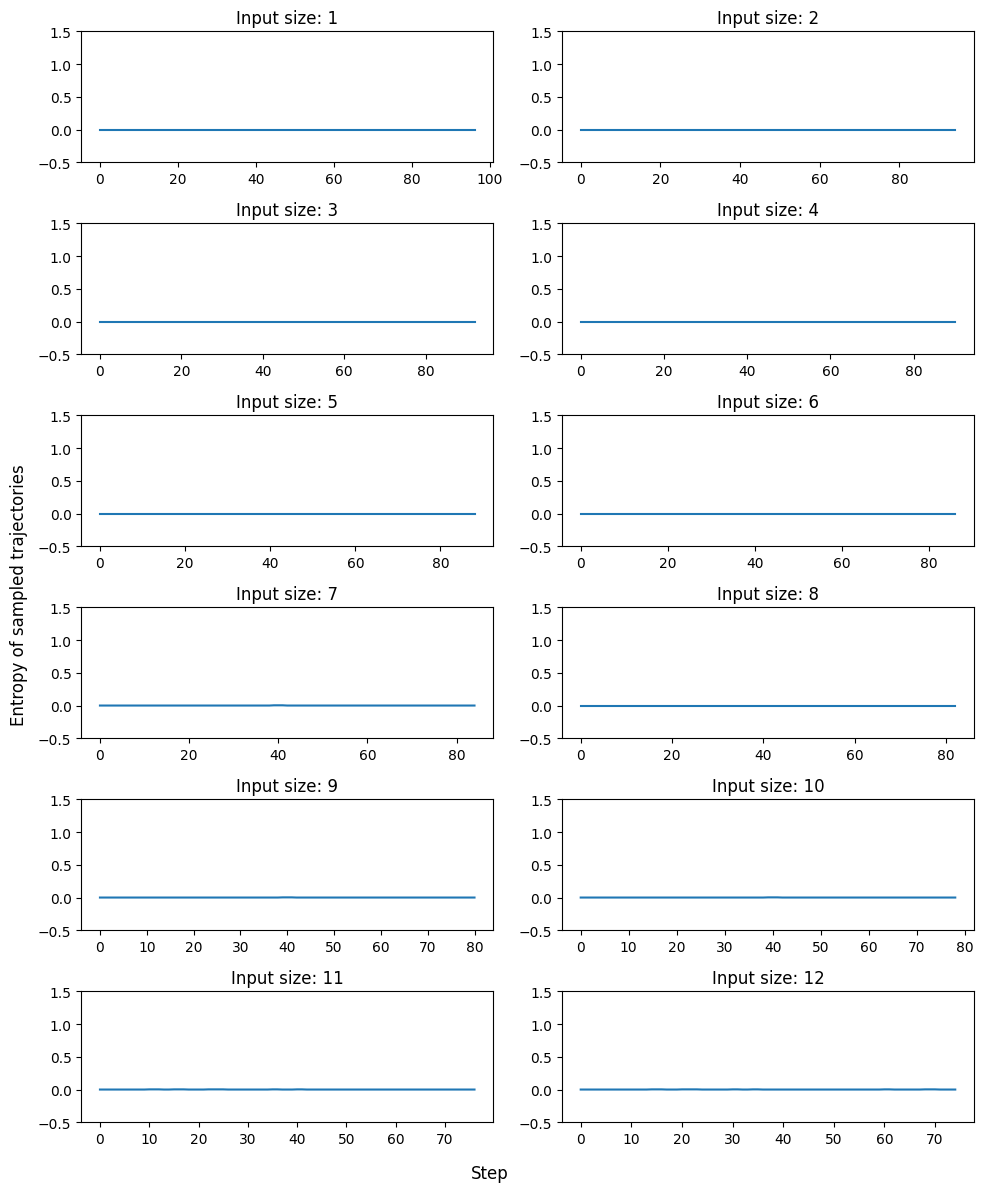

In [ ]:
checkpoint_i = 16

fig, axs = plt.subplots(
    int(np.ceil(len(match_results[0]) / 2)),
    2,
    figsize=(
        10,
        len(match_results[0])
    ),
)
axs = axs.flatten()

for plot_i, max_bits in enumerate(sorted(list(all_res["results"][checkpoint_i].keys()))):
    curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
    curr_actions = curr_actions.reshape((-1, num_evals, curr_actions.shape[-1]))
    train_max_decode_len = 100
    x_range = np.arange(0, curr_actions.shape[0])
    question_end_idx = 2 * max_bits + 1
    accum_action_ent = np.zeros((
        len(x_range),
        train_max_decode_len - question_end_idx,
    ))

    for entry_i, question_idx in enumerate(x_range):
        action_counts = np.zeros((
            train_max_decode_len - question_end_idx,
            dataset.output_space.n
        ))

        for step_i in range(train_max_decode_len - question_end_idx):
            for eval_i in range(num_evals):
                action_counts[step_i, curr_actions[question_idx, eval_i, question_end_idx + step_i]] += 1

        action_ent = scipy.stats.entropy(action_counts, axis=-1)
        accum_action_ent[entry_i] = action_ent

    axs[plot_i].plot(
        np.arange(train_max_decode_len - question_end_idx),
        np.mean(accum_action_ent, axis=0),
    )

    axs[plot_i].fill_between(
        np.arange(train_max_decode_len - question_end_idx),
        np.mean(accum_action_ent, axis=0) + np.std(accum_action_ent, axis=0) / num_evals,
        np.mean(accum_action_ent, axis=0) - np.std(accum_action_ent, axis=0) / num_evals,
        alpha=0.3
    )

    axs[plot_i].set_title(f"Input size: {max_bits}")
    axs[plot_i].set_ylim(-0.5, 1.5)

fig.supylabel('Entropy of sampled trajectories')
fig.supxlabel('Step')
fig.tight_layout()

In [ ]:
for plot_i, max_bits in enumerate(sorted(list(all_res["results"][checkpoint_i].keys()))):
    curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
    curr_obss = all_res["results"][checkpoint_i][max_bits]["observations"]
    question_end_idx = 2 * max_bits + 1
    print(curr_actions[0][question_end_idx:question_end_idx + 30])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0 0 1 3 0 0 0 0]
[1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0 0 1 3 0 0 0 0]
[1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0 0 1 3 0 0 0 0]
[1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0 0 1 3 0 0 0 0]
[1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0 0 1 3 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0 0 1 3 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 3 1 3 0 1 3 0 1 3 0 0 0 1 3 0 0 0 0 0 1 3 0 0 0 0 0 0]


In [ ]:
for plot_i, max_bits in enumerate(sorted(list(all_res["results"][checkpoint_i].keys()))):
    curr_actions = all_res["results"][checkpoint_i][max_bits]["actions"]
    curr_obss = all_res["results"][checkpoint_i][max_bits]["observations"]
    question_end_idx = 2 * max_bits + 1
    print(jnp.vstack((curr_obss[0][:30], curr_actions[0][1:31])))

[[1 2 0 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
[[0 0 2 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
[[0 1 0 2 0 0 1 3 5 5 3 5 3 0 5 3 0 0 5 3 0 0 0 5 3 0 0 0 0 0]
 [0 3 3 3 1 1 1 1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0 0 0]]
[[1 0 0 1 2 1 0 1 1 3 5 5 3 5 3 0 5 3 0 0 5 3 0 0 0 5 3 0 0 0]
 [0 3 3 3 3 1 1 1 1 1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0 0 0]]
[[1 0 0 0 1 2 1 1 0 1 0 3 5 5 3 5 3 0 5 3 0 0 5 3 0 0 0 5 3 0]
 [0 3 3 3 3 3 1 1 1 1 1 1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1 3 0]]
[[0 1 1 1 1 1 2 0 1 0 0 1 0 3 5 5 3 5 3 0 5 3 0 0 5 3 0 0 0 5]
 [0 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 3 1 3 0 1 3 0 0 1 3 0 0 0 1]]
[[0 1 0 0 1 0 1 2 0 0 1 1 1 0 0 3 5 5 3 5 3 0 5 3 0 0 5 3 0 0]
 [0 3 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 3 1 3 0 1 3 0 0 1 3 0 0]]
[[1 1 1 1 0 1 1 0 2 0 1 0 1 0 0 0 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 3 3 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

## Debug

In [ ]:
assert 0

AssertionError: 

In [ ]:
num_evals = 2
max_decode_len=20

num_bits = 3
curr_int = 2 ** num_bits
num_pairs = curr_int * curr_int
num_val = num_pairs - int(np.floor(num_pairs * train_val_ratio))
# batch_size = min(num_val, max_batch_size)
batch_size = 1
dataset = Addition(
    context_len=max_decode_len,
    max_int=curr_int,
    train=False,
    seed=eval_seed,
    sequence_type="question_only",
    train_val_ratio=train_val_ratio,
    right_to_left=right_to_left,
    num_repeats=None,
    shuffle=False,
    exact=True,
    predict_eos=predict_eos,
    num_cot_tokens=num_cot_tokens,
    p_curriculum=0.0,
    p_inject_noop=0.0,
    max_noops=0,
    noop_as_pad=False,
)

compute_returns = make_compute_returns(config, EOS_TOKEN)

print(f"Max int: {curr_int}, batch size: {batch_size}")

out_dim = int(dataset.output_space.n)
data_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=0,
)
data_iter = get_iter(data_loader, None, dtype)
batch = next(data_iter)
batch = {
    "sequence": np.repeat(batch["sequence"], num_evals, axis=0),
    "mask": np.repeat(batch["mask"], num_evals, axis=0),
    "target": np.repeat(batch["target"], num_evals, axis=0),
}

Max int: 8, batch size: 1


In [ ]:
class StepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: chex.PRNGKey
    observations: chex.Array
    actions: chex.Array
    answers: chex.Array
    pointer_correct: chex.Array
    is_prompt: chex.Array
    eos: chex.Array
    logits: chex.Array
    step_i: int = 0
    deterministic: int = 0
    """
    XXX: Set both to zero if we're using CoT tokens or predicting <EOS>

    XXX: Assume that all possible responses contain tokens with ID up to max_token_id_to_shift
         - You will have to include max_token_id_to_shift + 1 CoT tokens to get the code to run
    """
    correct_aware_shift: int = 0
    max_token_id_to_shift: int = 0


def predict_step(
    step_state: StepState,
):
    step_i = step_state.step_i
    rng, rng_step = jax.random.split(step_state.rng, 2)

    # Autoregressively decode
    module = nnx.merge(step_state.graphdef, step_state.rest, step_state.cache)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)
    logits = module({"sequence": step_state.observations[:, [step_i]],},)
    cache = nnx.state(module, nnx.Cache)

    logits = logits[:, 0]

    # Actual action taken, but output_tokens can be different
    action = jax.lax.cond(
        step_state.deterministic,
        lambda rng_step, logits: jnp.argmax(logits, axis=-1),
        jax.random.categorical,
        rng_step,
        logits,
    )

    is_prompt = step_state.is_prompt[:, step_i]
    pointer_correct = step_state.pointer_correct

    # Shift token by some amount if we know the steps are wrong
    curr_answers = step_state.answers[
        jnp.arange(len(pointer_correct)), pointer_correct
    ]

    pointer_correct = jnp.where(
        jnp.logical_and(
            jnp.logical_not(is_prompt),
            curr_answers == action,
        ),
        pointer_correct + 1,
        jnp.where(
            jnp.logical_and(
                step_state.answers[:, 0] != action,
                jnp.logical_not(is_prompt),
            ),
            0,
            1,
        )
    )

    output_tokens = jnp.where(
        jnp.logical_and(
            curr_answers != action,
            action <= step_state.max_token_id_to_shift,
        ),
        action + step_state.correct_aware_shift,
        action,
    )

    jax.debug.print(
        "step {w} is_prompt {v}: pointer {x} answer {y} pred {u} transition {z}",
        w=step_i,
        v=is_prompt,
        x=pointer_correct,
        y=curr_answers,
        u=action,
        z=output_tokens,
    )

    # Check for prompt boundary
    output_tokens = jnp.where(
        is_prompt,
        step_state.observations[:, step_i + 1],
        output_tokens,
    )

    # Check if the first EOS has been generated
    eos = jnp.logical_or(
        output_tokens == step_state.eos_token,
        step_state.eos[:, step_i],
    )

    # Update the entries on the i'th step
    observations = step_state.observations.at[:, step_i + 1].set(output_tokens)
    actions = step_state.actions.at[:, step_i + 1].set(action)
    eos = step_state.eos.at[:, step_i + 1].set(eos)
    all_logits = step_state.logits.at[:, step_i + 1].set(logits)

    step_state = StepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        observations=observations,
        actions=actions,
        answers=step_state.answers,
        pointer_correct=pointer_correct,
        is_prompt=step_state.is_prompt,
        eos=eos,
        step_i=step_i + 1,
        deterministic=step_state.deterministic,
        correct_aware_shift=step_state.correct_aware_shift,
        max_token_id_to_shift=step_state.max_token_id_to_shift,
        logits=all_logits,
    )

    return step_state

@nnx.jit(static_argnames=["out_dim"])
def rollout(
    graphdef: Any,
    cache: Any,
    rest: Any,
    rng: chex.PRNGKey,
    batch: Any,
    out_dim: int,
    eos_token: int,
    deterministic: int = 0,
    correct_aware_shift: int = 0,
    max_token_id_to_shift: int = 0,
):
    questions = batch["sequence"]
    answers = batch["target"]
    mask = batch["mask"]
    num_questions, max_step = questions.shape

    step_state = StepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        eos_token=eos_token,
        rng=rng,
        observations=questions,
        actions=jnp.zeros_like(questions, dtype=int),
        answers=answers,
        pointer_correct=jnp.ones((num_questions,), dtype=int),
        is_prompt=1 - mask,
        eos=jnp.zeros((num_questions, max_step)),
        deterministic=deterministic,
        correct_aware_shift=correct_aware_shift,
        max_token_id_to_shift=max_token_id_to_shift,
        logits=jnp.zeros((num_questions, max_step, out_dim)),
    )

    step_state = jax.lax.while_loop(
        lambda state: state.step_i < max_step - 1,
        predict_step,
        step_state,
    )

    return {
        "observations": step_state.observations,
        "actions": step_state.actions,
        "eos": step_state.eos,
        "is_prompt": step_state.is_prompt,
        "logits": step_state.logits,
    }


In [ ]:
config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

# Load model
last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
train_state = dill.load(
    open(os.path.join(learner_path, "models", last_step), "rb")
)

# print(train_state.params)
model = nnx.merge(
    train_state.graphdef,
    train_state.params,
    train_state.rest,
)

rng = jax.random.PRNGKey(eval_seed)
rng, rollout_rng = jax.random.split(rng)

# Sample next batch and evaluate
_, init_cache = make_autoregressive(
    model,
    max_decode_len=max_decode_len,
    batch_size=batch_size * num_evals,
    embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
    dtype=dtype,
    eval_mode=True,
)
cache = init_cache()
graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

rollout_res = rollout(
    graphdef,
    cache,
    rest,
    rollout_rng,
    batch,
    out_dim=out_dim,
    eos_token=EOS_TOKEN,
    deterministic=0,
    correct_aware_shift=getattr(config, "correctness_aware_tokens_offset", 0),
    max_token_id_to_shift=getattr(config, "max_token_id_to_shift", 0),
)

step 0 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [3 3] transition [3 3]
step 1 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [3 3] transition [3 3]
step 2 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [3 3] transition [3 3]
step 3 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [1 1] transition [5 5]
step 4 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [1 1] transition [5 5]
step 5 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [1 1] transition [5 5]
step 6 is_prompt [1. 1.]: pointer [1 1] answer [0 0] pred [1 1] transition [5 5]
step 7 is_prompt [0. 0.]: pointer [0 0] answer [0 0] pred [1 1] transition [5 5]
step 8 is_prompt [0. 0.]: pointer [0 0] answer [3 3] pred [1 1] transition [5 5]
step 9 is_prompt [0. 0.]: pointer [1 1] answer [3 3] pred [3 3] transition [3 3]
step 10 is_prompt [0. 0.]: pointer [0 0] answer [0 0] pred [1 1] transition [5 5]
step 11 is_prompt [0. 0.]: pointer [1 1] answer [3 3] pred [3 3] transition [3 3]
step 12 is_prompt [0. 0.]:

In [ ]:
rollout_res["observations"][0]

Array([0, 1, 0, 2, 0, 0, 1, 3, 5, 5, 3, 5, 3, 0, 1, 1, 5, 3, 0, 1, 1],      dtype=int32)

In [ ]:
rollout_res["observations"][0]

Array([0, 1, 0, 2, 0, 0, 1, 3, 5, 5, 3, 5, 3, 0, 1, 1, 5, 3, 0, 1, 1],      dtype=int32)

In [ ]:
rollout_res["actions"][0]

Array([0, 3, 3, 3, 1, 1, 1, 1, 1, 1, 3, 1, 3, 0, 1, 1, 1, 3, 0, 1, 1],      dtype=int32)